# EAGLE3 Per-Step Latency Decomposition

Analyze output of `scripts/sweep_eagle3_latency.py` — per-step cost broken into
`target_forward`, `eagle3_draft`, `verify_greedy`, `verify_overhead`, `post_verify`.

Oracle patch forces `accept_length = 0`, so `step_ms` is the raw cost of one speculative
iteration with **no acceptance benefit** — use this to characterize the tree-size cost curve,
not end-to-end speedup.

Input: `{BASE}/eagle3_sweep3d.json`

In [44]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
})

In [45]:
BENCH_PATH = "../results/qwen3_14b/eagle3_sweep3d.json"

with open(BENCH_PATH) as f:
    data = json.load(f)

vanilla_tpot = data['vanilla_tpot_ms']
all_df = pd.DataFrame(data['results'])
ok = all_df[all_df.get('error').isna()].reset_index(drop=True) if 'error' in all_df.columns else all_df.copy()
err = all_df[all_df.get('error').notna()].reset_index(drop=True) if 'error' in all_df.columns else pd.DataFrame()

print(f"Model: {data['model']}")
print(f"Draft: {data['draft_model']}")
print(f"Vanilla step_ms: {vanilla_tpot:.2f}")
print(f"Configs: {len(all_df)} total, {len(ok)} ok, {len(err)} errored")
print(f"Grid: topks={sorted(ok['topk'].unique())}, steps={sorted(ok['steps'].unique())}, budgets={sorted(ok['budget'].unique())}")

Model: Qwen/Qwen3-14B
Draft: AngelSlim/Qwen3-14B_eagle3
Vanilla step_ms: 25.32
Configs: 289 total, 242 ok, 47 errored
Grid: topks=[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)], steps=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)], budgets=[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024)]


## Summary table

All successful configs with their decomposition. `overhead_ms = step_ms - target_forward_ms - eagle3_draft_ms` captures verify + post_verify + misc.

In [46]:
view_cols = ['topk', 'steps', 'budget', 'step_ms', 'target_forward_ms',
             'eagle3_draft_ms', 'verify_overhead_ms', 'post_verify_ms',
             'verify_greedy_ms', 'n_samples']
summary = ok[view_cols].sort_values('step_ms').reset_index(drop=True)
summary.style.background_gradient(subset=['step_ms'], cmap='RdYlGn_r') \
             .background_gradient(subset=['verify_overhead_ms'], cmap='Reds') \
             .format({c: '{:.2f}' for c in view_cols if c.endswith('_ms')})

,topk,steps,budget,step_ms,target_forward_ms,eagle3_draft_ms,verify_overhead_ms,post_verify_ms,verify_greedy_ms,n_samples
0,4,1,1,28.41,8.33,0.43,17.71,0.97,0.01,1000.000000
1,8,1,1,28.44,8.46,0.44,17.60,1.00,0.01,1000.000000
2,16,1,1,28.45,8.46,0.44,17.60,1.01,0.01,1000.000000
3,2,1,1,28.53,8.46,0.43,17.69,1.00,0.01,1000.000000
4,4,1,2,29.47,8.99,0.48,17.97,0.99,0.01,1000.000000
5,1,1,1,29.50,8.87,0.48,18.14,0.95,0.02,1000.000000
6,16,1,2,29.50,8.85,0.48,18.13,0.98,0.01,1000.000000
7,8,1,2,29.59,8.98,0.50,18.05,1.01,0.02,1000.000000
8,2,1,2,29.62,8.98,0.50,18.07,1.02,0.02,1000.000000
9,8,2,1,29.76,8.41,1.39,17.69,1.34,0.01,1000.000000


## Stacked decomposition across all configs

Each bar is one config sorted by step_ms. Components stacked: target forward → EAGLE3 draft → verify overhead → post verify. The dashed line marks vanilla step latency.

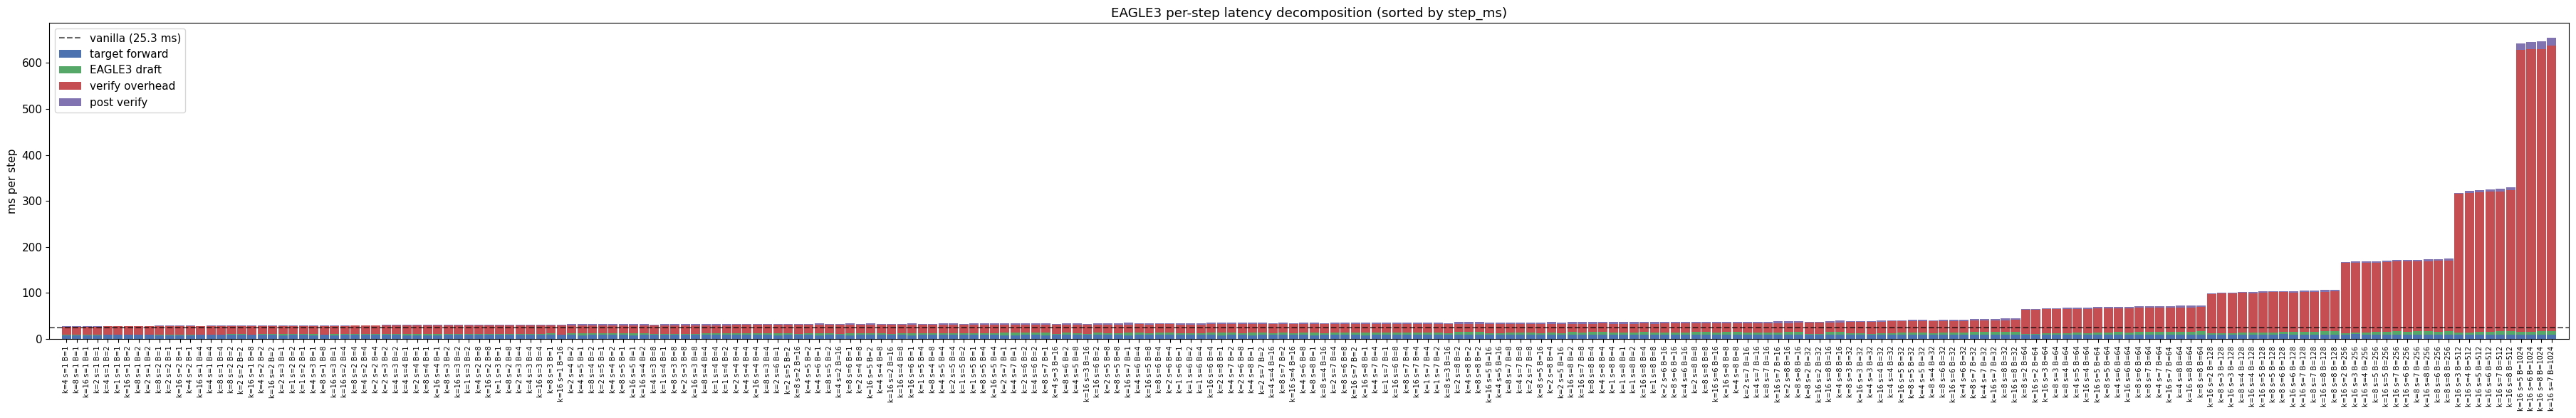

In [47]:
order = ok.sort_values('step_ms').reset_index(drop=True)
labels = [f"k={r.topk} s={r.steps} B={r.budget}" for r in order.itertuples()]

comps = [
    ('target_forward_ms', '#4c72b0', 'target forward'),
    ('eagle3_draft_ms',   '#55a868', 'EAGLE3 draft'),
    ('verify_overhead_ms','#c44e52', 'verify overhead'),
    ('post_verify_ms',    '#8172b2', 'post verify'),
]

fig, ax = plt.subplots(figsize=(max(14, 0.15 * len(order)), 6))
bottom = np.zeros(len(order))
for col, color, label in comps:
    ax.bar(range(len(order)), order[col], bottom=bottom, color=color, label=label, width=0.9)
    bottom = bottom + order[col].values

ax.axhline(vanilla_tpot, ls='--', color='black', alpha=0.6, label=f'vanilla ({vanilla_tpot:.1f} ms)')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('ms per step')
ax.set_title('EAGLE3 per-step latency decomposition (sorted by step_ms)')
ax.legend(loc='upper left')
ax.margins(x=0.005)
plt.tight_layout()
plt.show()

## Budget sweep per (topk, steps)

For each (topk, steps) combination with ≥2 successful budgets, plot step_ms and its components vs budget. Shows where verify overhead starts dominating.

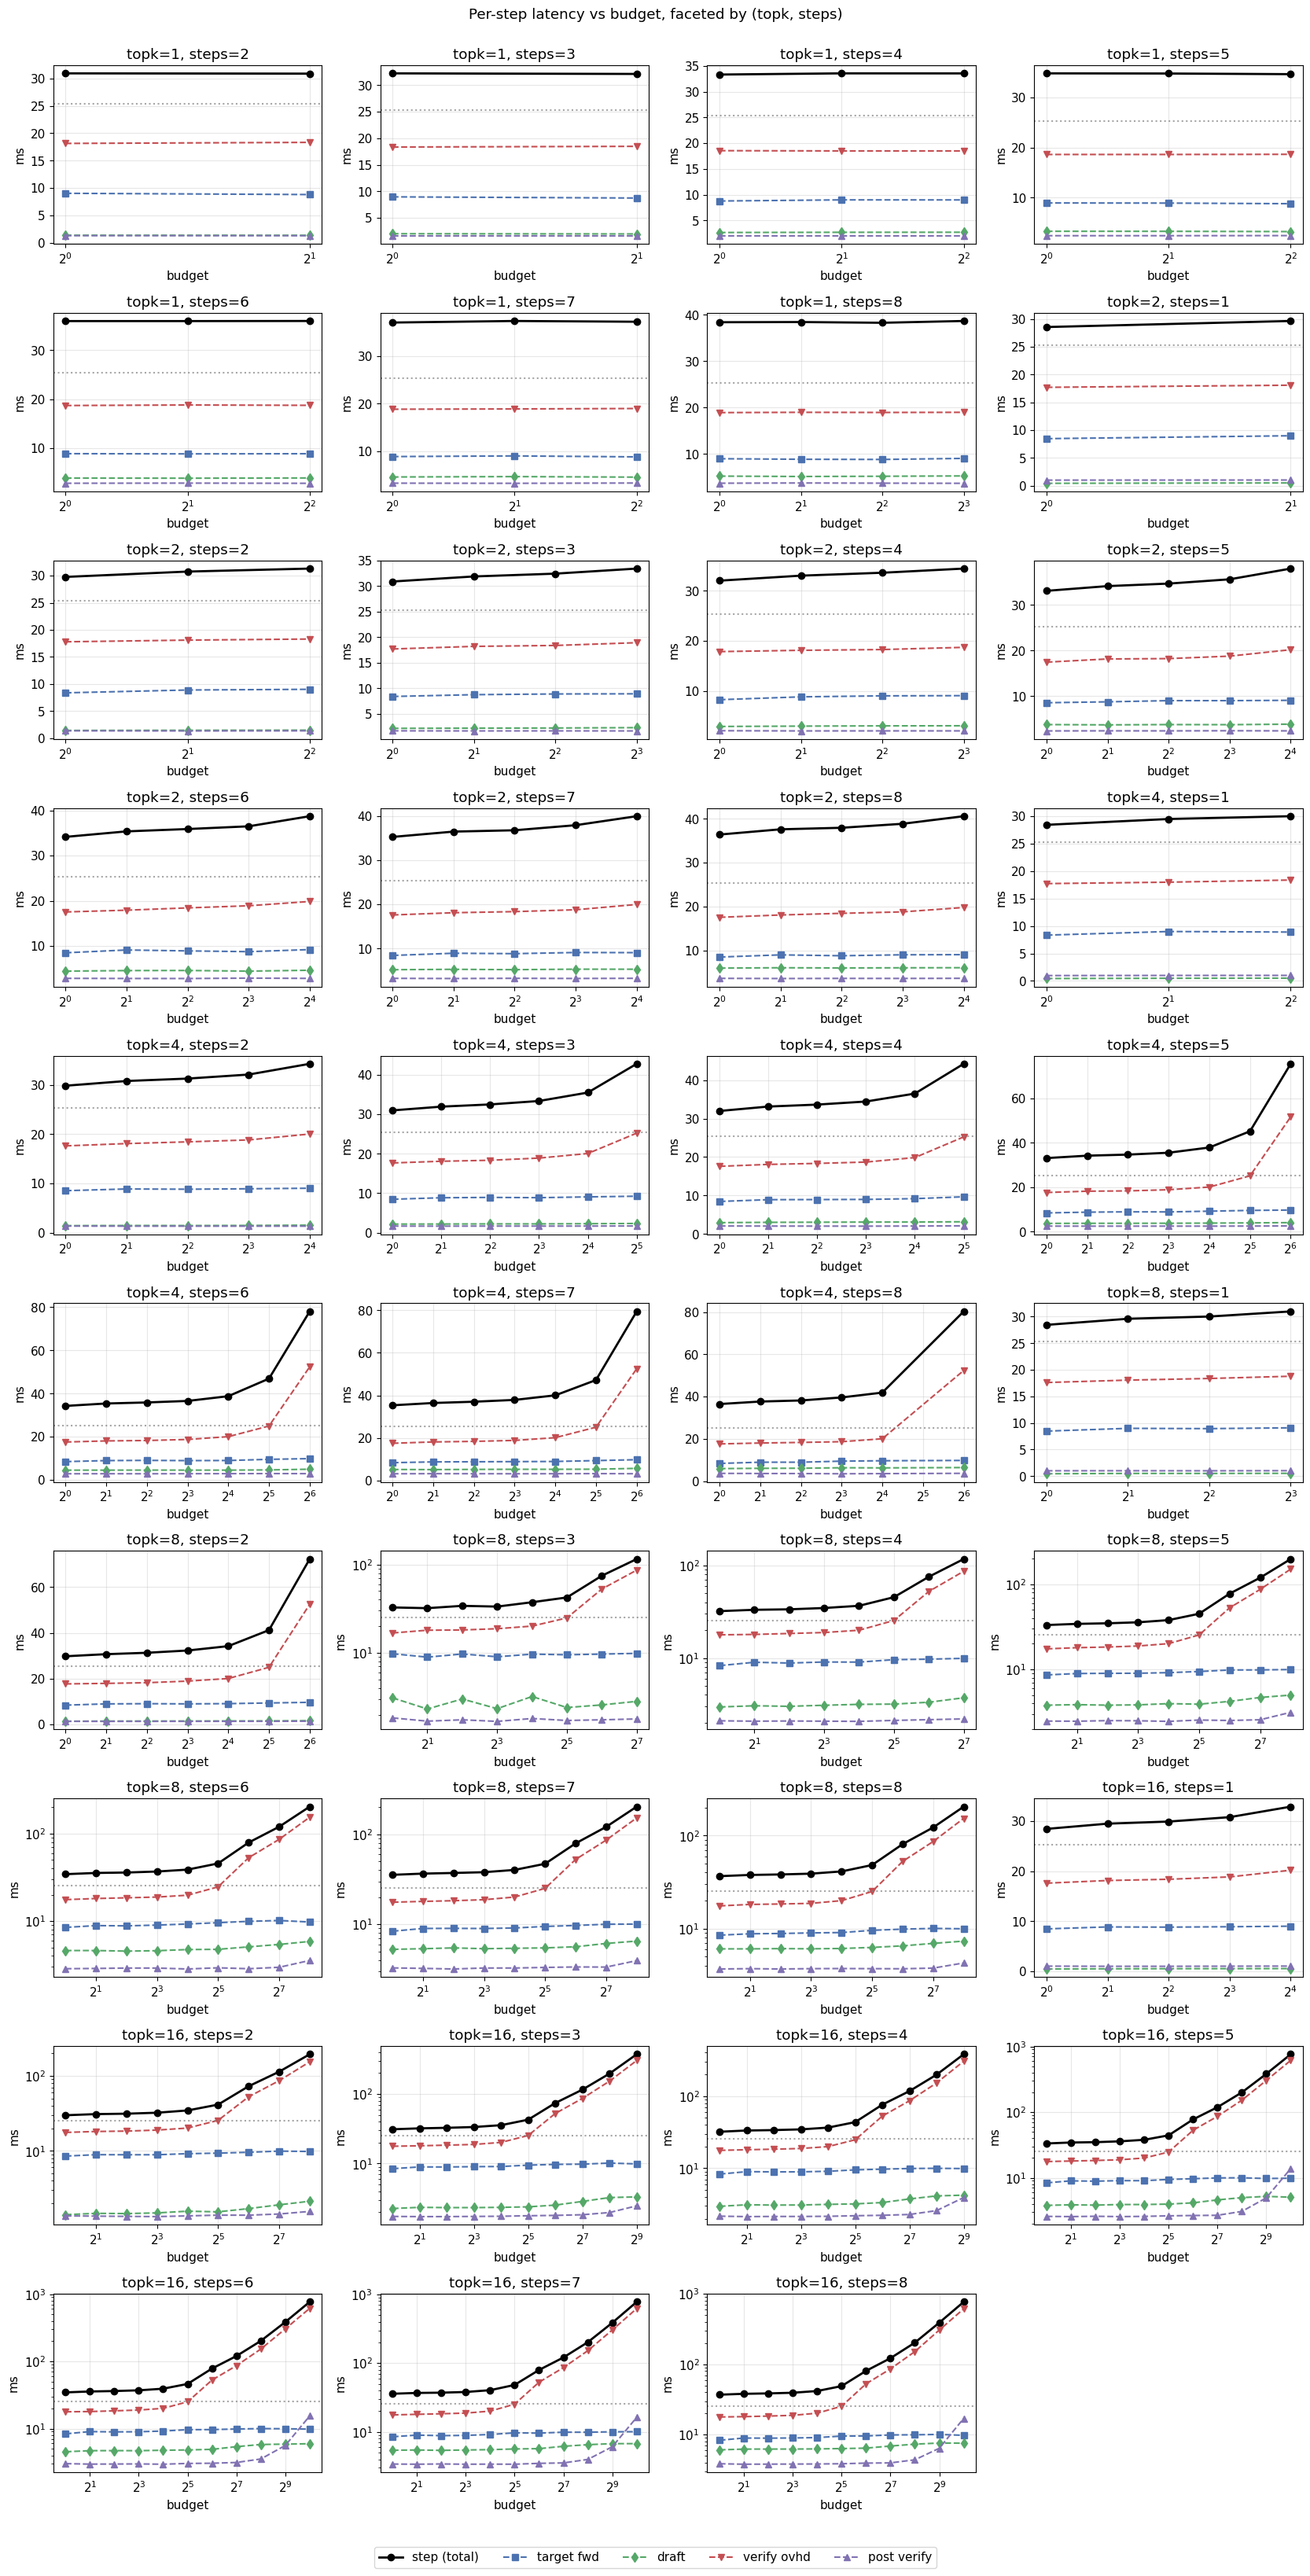

In [48]:
pairs = [(t, s) for (t, s), g in ok.groupby(['topk', 'steps']) if len(g) >= 2]
pairs.sort()

ncols = 4
nrows = int(np.ceil(len(pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                         sharey=False, squeeze=False)

for ax, (tk, st) in zip(axes.flat, pairs):
    g = ok[(ok.topk == tk) & (ok.steps == st)].sort_values('budget')
    x = g['budget'].values
    ax.plot(x, g['step_ms'], 'o-', color='black', lw=2, label='step (total)')
    ax.plot(x, g['target_forward_ms'], 's--', color='#4c72b0', label='target fwd')
    ax.plot(x, g['eagle3_draft_ms'], 'd--', color='#55a868', label='draft')
    ax.plot(x, g['verify_overhead_ms'], 'v--', color='#c44e52', label='verify ovhd')
    ax.plot(x, g['post_verify_ms'], '^--', color='#8172b2', label='post verify')
    ax.axhline(vanilla_tpot, ls=':', color='gray', alpha=0.7)
    ax.set_title(f'topk={tk}, steps={st}')
    ax.set_xlabel('budget')
    ax.set_ylabel('ms')
    ax.set_xscale('log', base=2)
    if len(x) > 1 and x.max() > 0 and g['step_ms'].max() / g['step_ms'].min() > 3:
        ax.set_yscale('log')
    ax.grid(alpha=0.3)

for ax in axes.flat[len(pairs):]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Per-step latency vs budget, faceted by (topk, steps)', y=1.0)
plt.tight_layout()
plt.show()

## Component isolation: how each knob affects each cost

1. **Draft cost** should scale with `steps` (draft model runs once per step).
2. **Target forward** should be nearly independent of all knobs (fixed by target model on fixed extend length).
3. **Verify overhead** should scale with `budget` (bigger tree → bigger mask → more work on GPU).

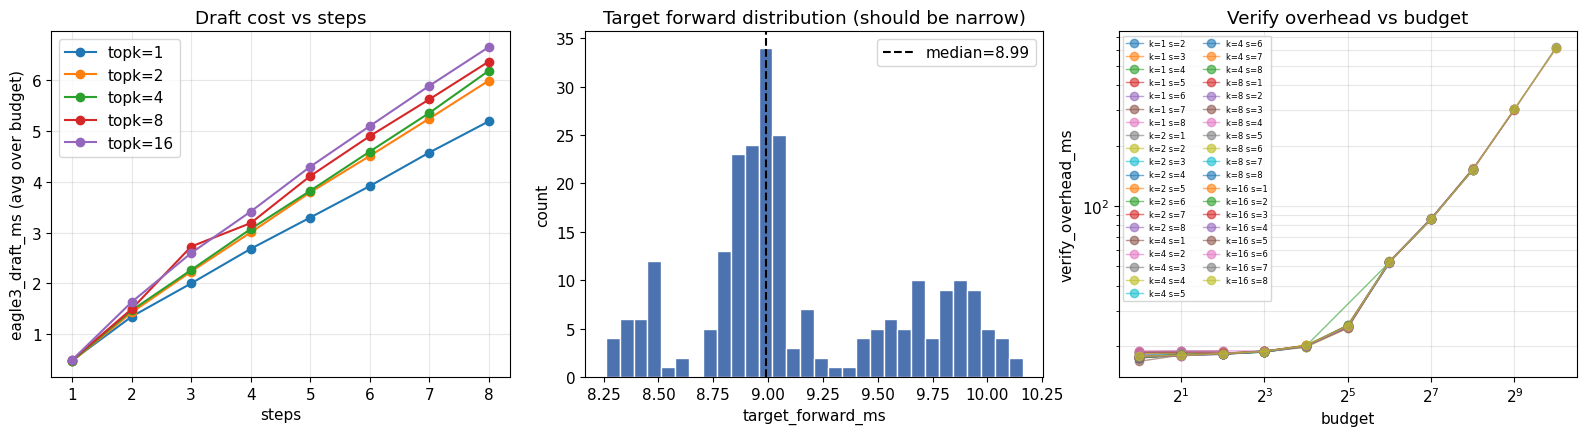

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. draft vs steps, colored by topk (avg over budget)
ax = axes[0]
for tk, g in ok.groupby('topk'):
    agg = g.groupby('steps')['eagle3_draft_ms'].mean().reset_index()
    ax.plot(agg['steps'], agg['eagle3_draft_ms'], 'o-', label=f'topk={tk}')
ax.set_xlabel('steps')
ax.set_ylabel('eagle3_draft_ms (avg over budget)')
ax.set_title('Draft cost vs steps')
ax.legend()
ax.grid(alpha=0.3)

# 2. target_forward distribution across all configs
ax = axes[1]
ax.hist(ok['target_forward_ms'], bins=30, color='#4c72b0', edgecolor='white')
ax.axvline(ok['target_forward_ms'].median(), color='black', ls='--',
           label=f'median={ok["target_forward_ms"].median():.2f}')
ax.set_xlabel('target_forward_ms')
ax.set_ylabel('count')
ax.set_title('Target forward distribution (should be narrow)')
ax.legend()

# 3. verify_overhead vs budget, separate line per (topk, steps)
ax = axes[2]
for (tk, st), g in ok.groupby(['topk', 'steps']):
    g = g.sort_values('budget')
    if len(g) >= 2:
        ax.plot(g['budget'], g['verify_overhead_ms'], 'o-', alpha=0.6, lw=1,
                label=f'k={tk} s={st}')
ax.set_xlabel('budget')
ax.set_ylabel('verify_overhead_ms')
ax.set_title('Verify overhead vs budget')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
# too many lines for a full legend — show only once outside
ax.legend(fontsize=6, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

## Heatmaps: step_ms over (topk, steps) at fixed budgets

One heatmap per budget value. Missing cells = error configs (budget exceeded SGLang `score_pool`).

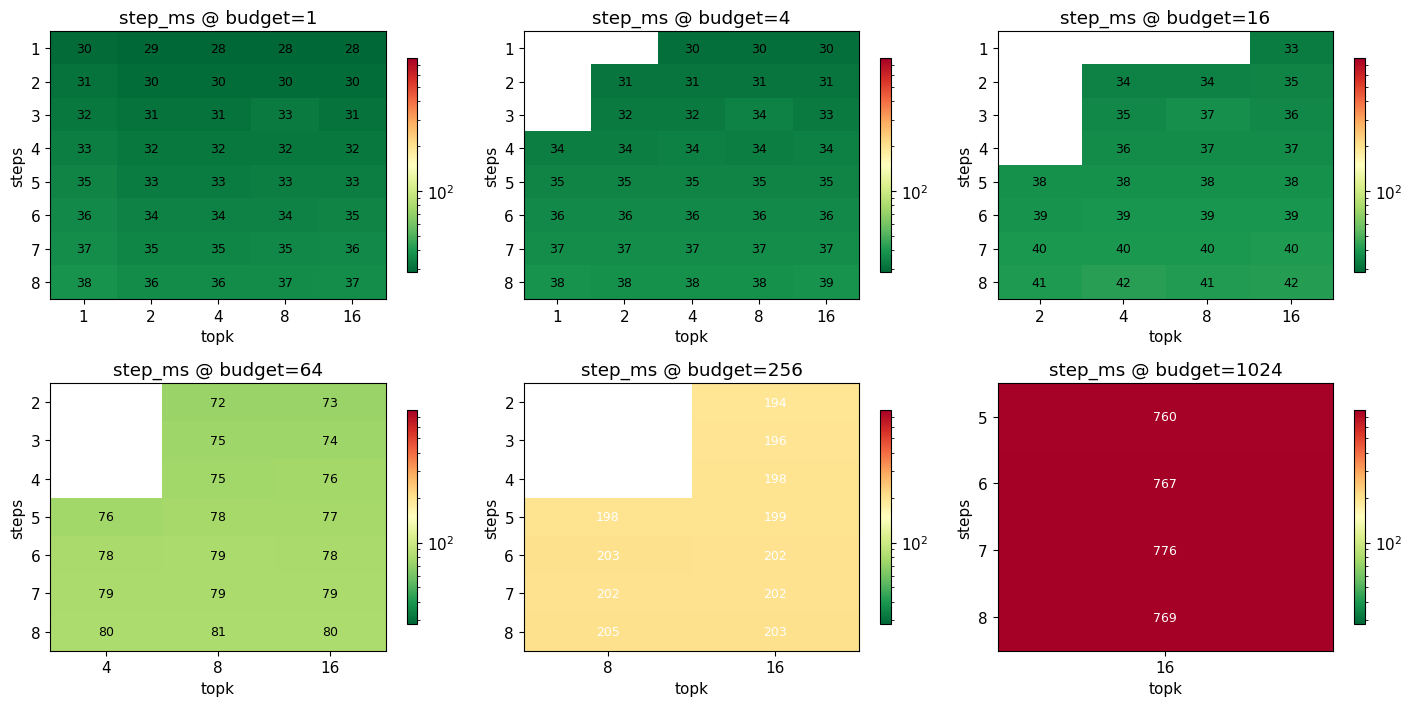

In [50]:
budgets_to_show = [1, 4, 16, 64, 256, 1024]
budgets_to_show = [b for b in budgets_to_show if b in ok['budget'].unique()]

ncols = min(3, len(budgets_to_show))
nrows = int(np.ceil(len(budgets_to_show) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.6 * nrows), squeeze=False)

vmin = ok['step_ms'].min()
vmax = ok['step_ms'].max()

for ax, B in zip(axes.flat, budgets_to_show):
    sub = ok[ok['budget'] == B]
    pivot = sub.pivot(index='steps', columns='topk', values='step_ms')
    pivot = pivot.sort_index().sort_index(axis=1)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                   norm=matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('topk')
    ax.set_ylabel('steps')
    ax.set_title(f'step_ms @ budget={B}')
    for (i, j), v in np.ndenumerate(pivot.values):
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    color='white' if v > (vmin * vmax) ** 0.5 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)

for ax in axes.flat[len(budgets_to_show):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Failed configs (for reference)

These hit `RuntimeError: selected index k out of range` in SGLang's `organize_draft_results`.
The score pool size is `topk + (steps-1) * topk²`, and budget must satisfy `budget ≤ score_pool + 1`.

In [51]:
if len(err) > 0:
    err_view = err[['topk', 'steps', 'budget', 'max_capacity']].copy()
    err_view['score_pool'] = err_view['topk'] + (err_view['steps'] - 1) * err_view['topk'] ** 2
    err_view['budget_limit'] = err_view['score_pool'] + 1
    err_view['over_by'] = err_view['budget'] - err_view['budget_limit']
    print(f'{len(err_view)} failed configs:')
    print(err_view.to_string(index=False))
else:
    print('No failed configs.')

47 failed configs:
 topk  steps  budget  max_capacity  score_pool  budget_limit  over_by
    2      4      16            30          14            15        1
    4      3      64            84          36            37       27
    4      4      64           340          52            53       11
    4      4     256           340          52            53      203
    4      5     256          1364          68            69      187
    8      3     256           584         136           137      119
    8      4     256          4680         200           201       55
    2      5      32            62          18            19       13
    2      6      32           126          22            23        9
    2      6      64           126          22            23       41
    2      7      32           254          26            27        5
    2      7      64           254          26            27       37
    2      7     128           254          26            27      101
 

## Budget (num_draft_tokens) sweep — fixed topk=8, steps=5

**target cost** = `target_forward_ms + verify_overhead_ms` (real target GPU wall time; coarse `target_forward_ms` alone undercounts async GPU completion).
**draft cost** = EAGLE3 draft forward.

Budget shown as actual numbers (log-spaced ticks).

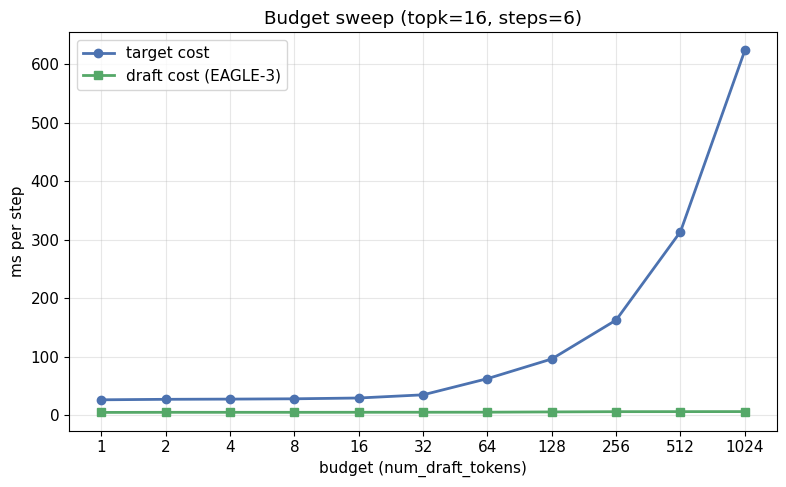

' budget  target_cost_ms  eagle3_draft_ms\n      1           26.11             4.52\n      2           26.94             4.69\n      4           27.29             4.70\n      8           27.82             4.69\n     16           29.18             4.76\n     32           34.63             4.81\n     64           62.32             4.91\n    128           95.98             5.38\n    256          162.54             5.80\n    512          313.74             5.87\n   1024          623.72             5.95'

In [52]:
import matplotlib.ticker as mtick

# True target cost = target_forward_ms + verify_overhead_ms
# (oracle_patch's target_forward_ms misses async GPU completion; the missing time
#  leaks into verify_overhead. Sum of both = real target forward wall time.)
ok_adj = ok.assign(target_cost_ms=ok["target_forward_ms"] + ok["verify_overhead_ms"])

fix_topk, fix_steps = 16, 6
sub = ok_adj[(ok_adj.topk == fix_topk) & (ok_adj.steps == fix_steps)].sort_values("budget")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub["budget"], sub["target_cost_ms"], "o-", color="#4c72b0",
        lw=2, label="target cost")
ax.plot(sub["budget"], sub["eagle3_draft_ms"], "s-", color="#55a868",
        lw=2, label="draft cost (EAGLE-3)")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mtick.ScalarFormatter())
ax.xaxis.set_major_locator(mtick.FixedLocator(list(sub["budget"])))
ax.set_xlabel("budget (num_draft_tokens)")
ax.set_ylabel("ms per step")
ax.set_title(f"Budget sweep (topk={fix_topk}, steps={fix_steps})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
sub[["budget", "target_cost_ms", "eagle3_draft_ms"]].to_string(index=False)

## Branch (topk) sweep — fixed budget=64, steps=5

Same `target cost` / `draft cost` definitions as above.

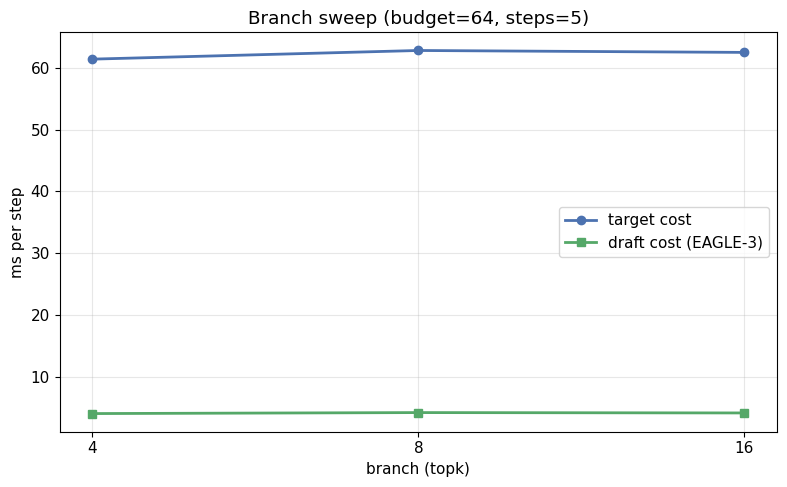

' topk  target_cost_ms  eagle3_draft_ms\n    4           61.41             4.05\n    8           62.81             4.21\n   16           62.50             4.15'

In [53]:
fix_budget, fix_steps = 64, 5
sub = ok_adj[(ok_adj.budget == fix_budget) & (ok_adj.steps == fix_steps)].sort_values("topk")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub["topk"], sub["target_cost_ms"], "o-", color="#4c72b0",
        lw=2, label="target cost")
ax.plot(sub["topk"], sub["eagle3_draft_ms"], "s-", color="#55a868",
        lw=2, label="draft cost (EAGLE-3)")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mtick.ScalarFormatter())
ax.xaxis.set_major_locator(mtick.FixedLocator(list(sub["topk"])))
ax.set_xlabel("branch (topk)")
ax.set_ylabel("ms per step")
ax.set_title(f"Branch sweep (budget={fix_budget}, steps={fix_steps})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
sub[["topk", "target_cost_ms", "eagle3_draft_ms"]].to_string(index=False)

## Depth (steps) sweep — fixed budget=256, topk=16

Same `target cost` / `draft cost` definitions.

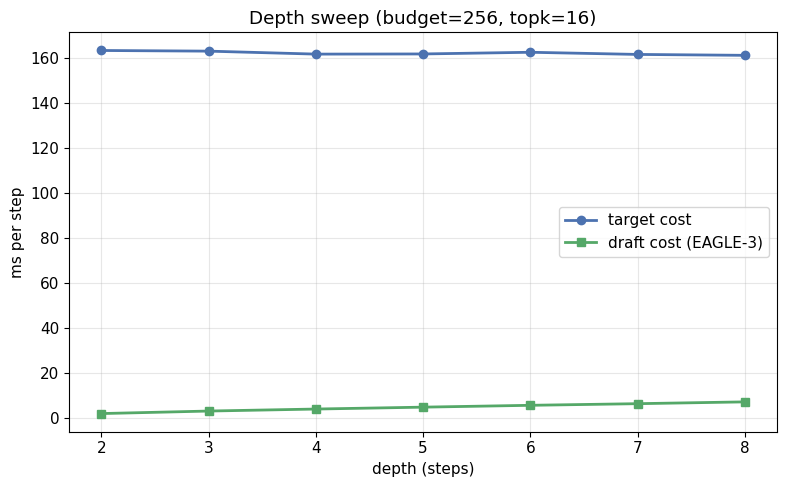

' steps  target_cost_ms  eagle3_draft_ms\n     2          163.33             2.13\n     3          163.04             3.25\n     4          161.72             4.14\n     5          161.79             4.98\n     6          162.54             5.80\n     7          161.58             6.52\n     8          161.18             7.32'

In [59]:
fix_budget, fix_topk = 256, 16
sub = ok_adj[(ok_adj.budget == fix_budget) & (ok_adj.topk == fix_topk)].sort_values("steps")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub["steps"], sub["target_cost_ms"], "o-", color="#4c72b0",
        lw=2, label="target cost")
ax.plot(sub["steps"], sub["eagle3_draft_ms"], "s-", color="#55a868",
        lw=2, label="draft cost (EAGLE-3)")
ax.set_xlabel("depth (steps)")
ax.set_ylabel("ms per step")
ax.set_title(f"Depth sweep (budget={fix_budget}, topk={fix_topk})")
ax.set_xticks(list(sub["steps"]))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
sub[["steps", "target_cost_ms", "eagle3_draft_ms"]].to_string(index=False)

## Draft tree visualization

Load the first draft record from `trees/topk{T}_steps{S}_budget{B}.jsonl` and render the tree.
Prefers graphviz (via `pydot`); falls back to networkx hierarchical layout if graphviz is unavailable.

Nodes labelled with token id + decoded text. No per-node score displayed.

In [67]:
# Config to visualize
TREE_TOPK, TREE_STEPS, TREE_BUDGET = 8, 5, 64
TREE_STEP_INDEX = 49   # 0=first draft step, 49=50th
TREE_PREV_CONTEXT = 2  # how many prior tokens to include before ROOT
TREE_DIR = Path(BENCH_PATH).resolve().parent / "trees"
TREE_PATH = TREE_DIR / f"topk{TREE_TOPK}_steps{TREE_STEPS}_budget{TREE_BUDGET}.jsonl"

# Load the N-th draft record + previous context records
ctx_start = max(0, TREE_STEP_INDEX - TREE_PREV_CONTEXT)
records = []
with open(TREE_PATH) as f:
    for idx, line in enumerate(f):
        if idx < ctx_start:
            continue
        if idx > TREE_STEP_INDEX:
            break
        records.append(json.loads(line))
if not records:
    raise IndexError(f"Tree log has fewer than {TREE_STEP_INDEX + 1} records")

rec = records[-1]
tree = rec["eagle3_tree"]
token_ids = tree["token_ids"]
parents = tree["parents"]

# Root token: position 0 of candidates (= verified bonus from previous step)
root_token = rec["eagle3"][0][0]
# This step's accepted bonus (target argmax at root position). With oracle patch
# this is the only token actually committed; it will become next step's ROOT.
bonus_token = rec["tokens"][0][0]
# Prev context: root tokens of preceding steps (chain of verified tokens)
prev_tokens = [r["eagle3"][0][0] for r in records[:-1]]

# Accepted draft node indices = direct children of ROOT whose token_id matches
# the bonus target predicted at root position. These are what would have been
# accepted in normal (non-oracle) EAGLE3 verification at depth 1.
accepted_idx = [i for i, (tid, p) in enumerate(zip(token_ids, parents))
                if p == -1 and tid == bonus_token]

print(f"Tree: {len(token_ids)} draft nodes, step_index={TREE_STEP_INDEX}, "
      f"req_id={rec['req_id'][:16]}...")
print(f"ROOT token id: {root_token}   (verified from previous step)")
print(f"Bonus token id: {bonus_token} (target predicted, would be next ROOT)")
print(f"Would-be-accepted root children matching bonus: {accepted_idx}")
print(f"Prev {len(prev_tokens)} root tokens: {prev_tokens}")

# Decode tokens for readable labels
try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(data["model"], trust_remote_code=True)
    decoded = [tok.decode([tid]) for tid in token_ids]
    root_decoded = tok.decode([root_token])
    bonus_decoded = tok.decode([bonus_token])
    prev_decoded = [tok.decode([t]) for t in prev_tokens]
    print(f"ROOT: {root_decoded!r}  |  BONUS: {bonus_decoded!r}")
    print(f"Prev decoded: {prev_decoded!r}")
except Exception as e:
    print(f"(tokenizer load failed: {e}; showing token ids only)")
    decoded = [""] * len(token_ids)
    root_decoded = ""; bonus_decoded = ""
    prev_decoded = [""] * len(prev_tokens)

def node_label(i):
    txt = decoded[i].replace("\n", "\\n").replace('"', '\\"').strip()
    return f"{token_ids[i]}\n{txt!r}" if txt else f"{token_ids[i]}"

def ctx_label(tid, txt):
    t = txt.replace("\n", "\\n").replace('"', '\\"').strip()
    return f"{tid}\n{t!r}" if t else f"{tid}"

Tree: 63 draft nodes, step_index=49, req_id=3fba6d7b561442d8...
ROOT token id: 64828   (verified from previous step)
Bonus token id: 18303 (target predicted, would be next ROOT)
Would-be-accepted root children matching bonus: [14]
Prev 2 root tokens: [8909, 8909]
ROOT: ' divides'  |  BONUS: ' breaks'
Prev decoded: [' Like', ' Like']


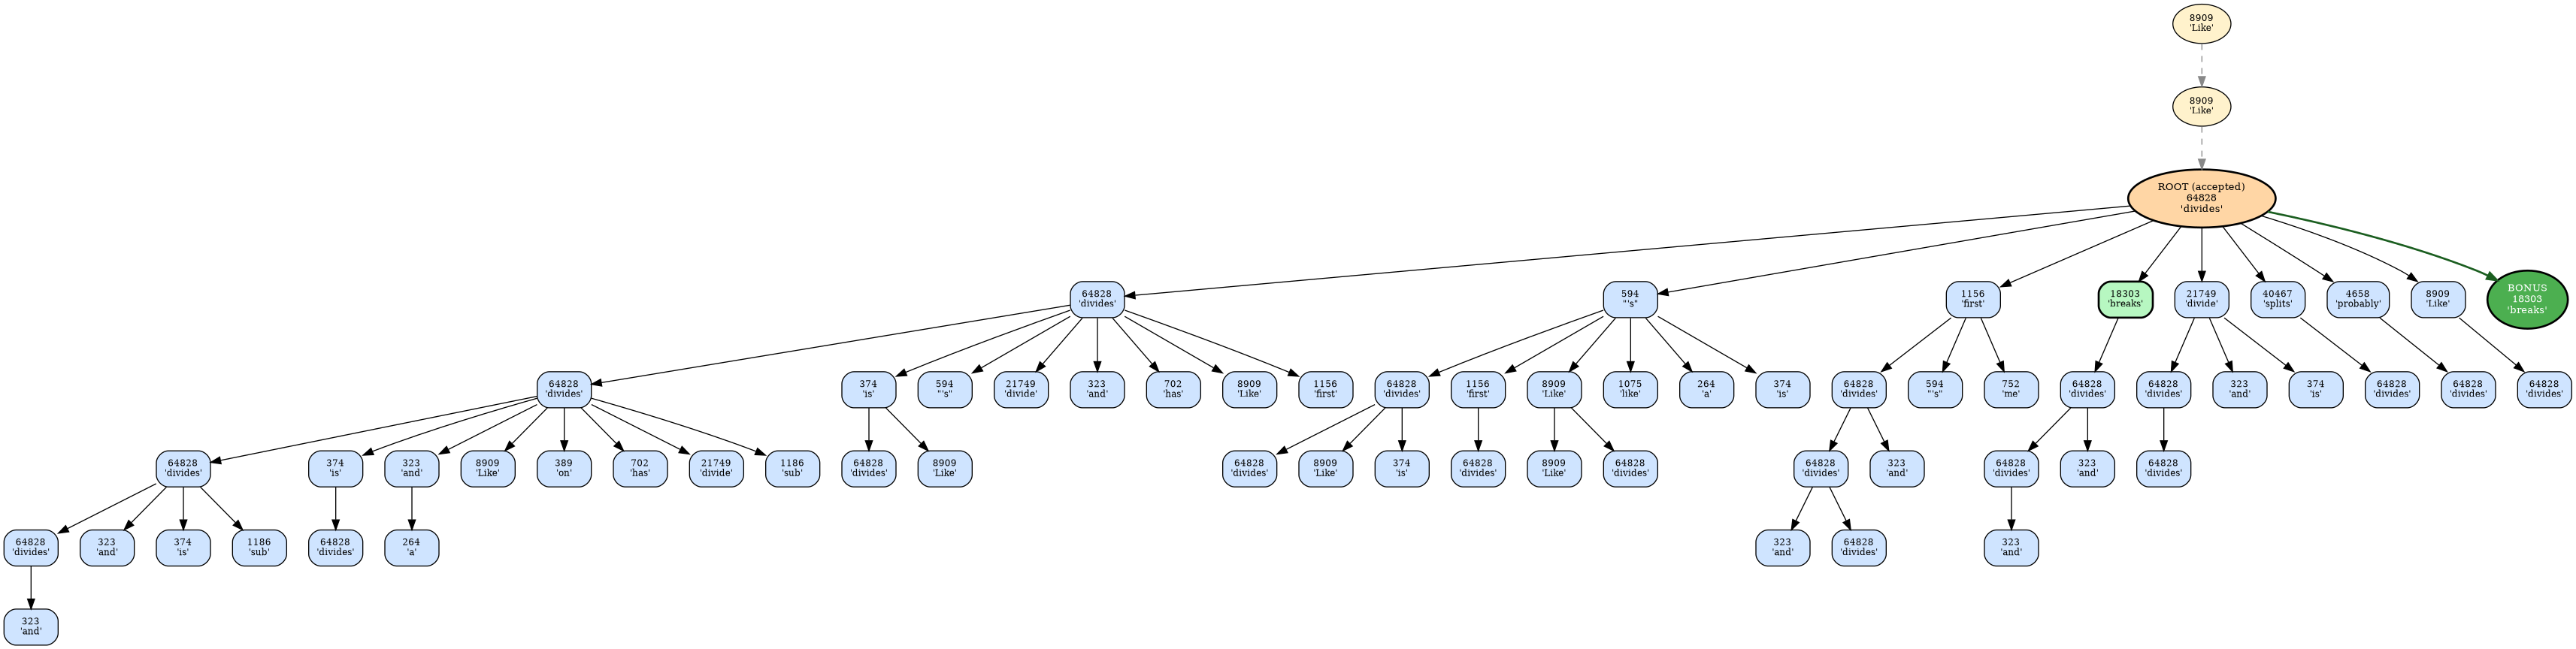

Rendered 63 draft + 2 ctx + ROOT + BONUS via graphviz
  accepted (green) node indices: [14]
  saved: tree_topk8_steps5_budget64_step49.png, tree_topk8_steps5_budget64_step49.svg, tree_topk8_steps5_budget64_step49.dot
  dir:   ../tree_plots


In [68]:
# Output location for saved tree images
TREE_OUT_DIR = Path(BENCH_PATH).parent.parent.parent / "tree_plots"
TREE_OUT_DIR.mkdir(parents=True, exist_ok=True)
base = f"tree_topk{TREE_TOPK}_steps{TREE_STEPS}_budget{TREE_BUDGET}_step{TREE_STEP_INDEX}"

# Color scheme
CTX_COLOR   = "#fff2cc"  # yellow-ish: previous-context tokens
ROOT_COLOR  = "#ffd6a5"  # orange: verified ROOT (previously accepted)
DRAFT_COLOR = "#cfe4ff"  # blue: unaccepted draft
ACCEPT_COLOR= "#b7f7c1"  # green: draft node matching bonus (would-be-accepted)
BONUS_COLOR = "#4caf50"  # darker green: the bonus token itself (target-predicted next)

rendered = False
try:
    import pydot
    g = pydot.Dot(graph_type="digraph", rankdir="TB", nodesep="0.3", ranksep="0.6")

    # Context chain: ctx0 -> ctx1 -> ... -> ROOT
    prev_node_ids = []
    for k, (tid, txt) in enumerate(zip(prev_tokens, prev_decoded)):
        nid = f"ctx{k}"
        g.add_node(pydot.Node(nid, label=ctx_label(tid, txt),
                              shape="ellipse", style="filled",
                              fillcolor=CTX_COLOR, fontsize="9"))
        prev_node_ids.append(nid)

    # ROOT (verified, highlighted)
    g.add_node(pydot.Node("root",
                          label=f"ROOT (accepted)\n{ctx_label(root_token, root_decoded)}",
                          shape="ellipse", style="filled,bold",
                          fillcolor=ROOT_COLOR, fontsize="10"))
    for prev_nid, next_nid in zip(prev_node_ids, prev_node_ids[1:] + ["root"]):
        g.add_edge(pydot.Edge(prev_nid, next_nid, style="dashed", color="#888888"))

    # Draft tree nodes — recolor accepted ones
    accepted_set = set(accepted_idx)
    for i, tid in enumerate(token_ids):
        color = ACCEPT_COLOR if i in accepted_set else DRAFT_COLOR
        style = "rounded,filled,bold" if i in accepted_set else "rounded,filled"
        g.add_node(pydot.Node(str(i), label=node_label(i),
                              shape="box", style=style,
                              fillcolor=color, fontsize="9"))
    for i, p in enumerate(parents):
        src = "root" if p == -1 else str(p)
        g.add_edge(pydot.Edge(src, str(i)))

    # Add the BONUS token node after ROOT (shown separately to indicate what
    # target actually committed this step — becomes next step's ROOT)
    g.add_node(pydot.Node("bonus",
                          label=f"BONUS\n{ctx_label(bonus_token, bonus_decoded)}",
                          shape="ellipse", style="filled,bold",
                          fillcolor=BONUS_COLOR, fontcolor="white", fontsize="10"))
    g.add_edge(pydot.Edge("root", "bonus", color="#1b5e20", penwidth="2"))

    png_path = TREE_OUT_DIR / f"{base}.png"
    svg_path = TREE_OUT_DIR / f"{base}.svg"
    dot_path = TREE_OUT_DIR / f"{base}.dot"
    g.write_png(str(png_path))
    g.write_svg(str(svg_path))
    g.write_raw(str(dot_path))

    from IPython.display import Image, display
    display(Image(str(png_path)))
    print(f"Rendered {len(token_ids)} draft + {len(prev_tokens)} ctx + ROOT + BONUS via graphviz")
    print(f"  accepted (green) node indices: {accepted_idx}")
    print(f"  saved: {png_path.name}, {svg_path.name}, {dot_path.name}")
    print(f"  dir:   {TREE_OUT_DIR}")
    rendered = True
except Exception as e:
    print(f"graphviz path failed: {e!r}")
    print("Falling back to networkx...")

if not rendered:
    import networkx as nx
    G = nx.DiGraph()
    prev_node_ids = []
    for k, (tid, txt) in enumerate(zip(prev_tokens, prev_decoded)):
        nid = f"ctx{k}"
        G.add_node(nid, kind="ctx")
        prev_node_ids.append(nid)
    G.add_node("root", kind="root")
    G.add_node("bonus", kind="bonus")
    for prev_nid, next_nid in zip(prev_node_ids, prev_node_ids[1:] + ["root"]):
        G.add_edge(prev_nid, next_nid)
    G.add_edge("root", "bonus")
    accepted_set = set(accepted_idx)
    for i in range(len(token_ids)):
        G.add_node(i, kind="accept" if i in accepted_set else "draft")
    for i, p in enumerate(parents):
        G.add_edge("root" if p == -1 else p, i)

    levels = {}
    for k, nid in enumerate(prev_node_ids):
        levels[nid] = k
    levels["root"] = len(prev_node_ids)
    for i, p in enumerate(parents):
        parent = "root" if p == -1 else p
        levels[i] = levels.get(parent, len(prev_node_ids)) + 1
    levels["bonus"] = max(levels.values()) + 1
    max_level = max(levels.values())
    by_level = {}
    for n, lv in levels.items():
        by_level.setdefault(lv, []).append(n)
    pos = {}
    for lv, nodes in by_level.items():
        for j, n in enumerate(nodes):
            x = (j + 1) / (len(nodes) + 1)
            pos[n] = (x, -lv)
    color_map = {"ctx": CTX_COLOR, "root": ROOT_COLOR, "draft": DRAFT_COLOR,
                 "accept": ACCEPT_COLOR, "bonus": BONUS_COLOR}
    node_colors = [color_map[G.nodes[n]["kind"]] for n in G.nodes]

    fig, ax = plt.subplots(figsize=(max(10, len(by_level.get(len(prev_node_ids) + 1, [])) * 2),
                                     2.2 * (max_level + 1)))
    nx.draw(G, pos, node_color=node_colors, with_labels=False,
            node_size=700, arrows=True, arrowsize=8, ax=ax, width=0.6)
    for n, (x, y) in pos.items():
        if n in prev_node_ids:
            idx = int(n[3:]); lbl = ctx_label(prev_tokens[idx], prev_decoded[idx])
        elif n == "root":
            lbl = f"ROOT\n{ctx_label(root_token, root_decoded)}"
        elif n == "bonus":
            lbl = f"BONUS\n{ctx_label(bonus_token, bonus_decoded)}"
        else:
            lbl = node_label(n)
        ax.text(x, y - 0.15, lbl, ha="center", va="top", fontsize=7)
    ax.set_title(f"Draft tree + ctx (topk={TREE_TOPK}, steps={TREE_STEPS}, "
                 f"budget={TREE_BUDGET}, step={TREE_STEP_INDEX})")
    ax.set_axis_off()
    plt.tight_layout()
    png_path = TREE_OUT_DIR / f"{base}.png"
    pdf_path = TREE_OUT_DIR / f"{base}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print(f"Rendered {len(token_ids)} draft + ctx + ROOT + BONUS via networkx")
    print(f"  accepted node indices: {accepted_idx}")
    print(f"  saved: {png_path.name}, {pdf_path.name}")